## Section 1 — Problem Statement + Data Description

### Problem Statement

you are given two tabular datasets containing lab-measured chemical properties of red and white wines. The goal is to build a **multi-class classification** model that predicts the wine's **quality score** (integer rating), and then conduct a **comparative study** across:

1. **Red vs White dataset** — Which dataset is easier to predict and why?
2. **Model vs Model** — Which model performs better on each dataset and why?
3. **Class-level difficulty** — Which quality scores are hardest to classify?

The same models (Logistic Regression and Random Forest) and same evaluation metrics (Accuracy, Confusion Matrix, Classification Report, Macro F1-Score) are used on both datasets to ensure a **fair comparison**.

### Data Description

Each row represents **one wine sample** with 11 numeric chemical/physical feature columns and one integer target column `quality`.

| Feature | Description |
|---|---|
| fixed acidity | Stable acids in wine |
| volatile acidity | Acetic acid — high values can reduce quality |
| citric acid | Adds freshness |
| residual sugar | Sugar remaining after fermentation |
| chlorides | Salt content |
| free sulfur dioxide | Free SO₂ (preservative) |
| total sulfur dioxide | Total SO₂ (preservative) |
| density | Related to alcohol and sugar content |
| pH | Overall acidity level |
| sulphates | Stability / preservation agent |
| alcohol | Alcohol percentage (%) |

**Expected challenges:**
- **Class imbalance**: Quality scores 5 and 6 dominate; scores 3 and 8/9 are very rare.
- **Overlapping classes**: Adjacent quality levels (e.g., 5 vs 6) share very similar feature distributions, making separation difficult.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score,
                             ConfusionMatrixDisplay)



# Task:1

In [59]:
# Load both datasets (sep=';' as required) 
red_df   = pd.read_csv(r'C:\Users\DELL\Desktop\Herovired All  Assignment\ML assignment\winequality-red.csv',   sep=';')
white_df = pd.read_csv(r'C:\Users\DELL\Desktop\Herovired All  Assignment\ML assignment\winequality-white.csv', sep=';')

df.shape
df.info()
df.describe()
   



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


---
## Task 2

In [60]:
for name, df in [(' RED WINE', red_df), ('WHITE WINE', white_df)]:

    missing = df.isnull().sum()
    print(f"  Missing Values : {missing.sum()}")


    dups = df.duplicated().sum()
    print(f"  Duplicate Rows : {dups}")

  Missing Values : 0
  Duplicate Rows : 240
  Missing Values : 0
  Duplicate Rows : 937


In [61]:
    
# ── Class Distribution (counts + percentages) ────────────────────────────────
for name, df in [('RED WINE', red_df), ('WHITE WINE', white_df)]:
    counts = df['quality'].value_counts().sort_index()
    pct    = (counts / len(df) * 100).round(2)
    dist   = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
    print(f"  {name} — Quality Distribution")
    print(dist.to_string())
    print(f"  Total samples: {len(df)}")
    print()




  

  RED WINE — Quality Distribution
         Count  Percentage (%)
quality                       
3           10            0.63
4           53            3.31
5          681           42.59
6          638           39.90
7          199           12.45
8           18            1.13
  Total samples: 1599

  WHITE WINE — Quality Distribution
         Count  Percentage (%)
quality                       
3           20            0.41
4          163            3.33
5         1457           29.75
6         2198           44.88
7          880           17.97
8          175            3.57
9            5            0.10
  Total samples: 4898



##### 4. plot a bar chart of quality counts

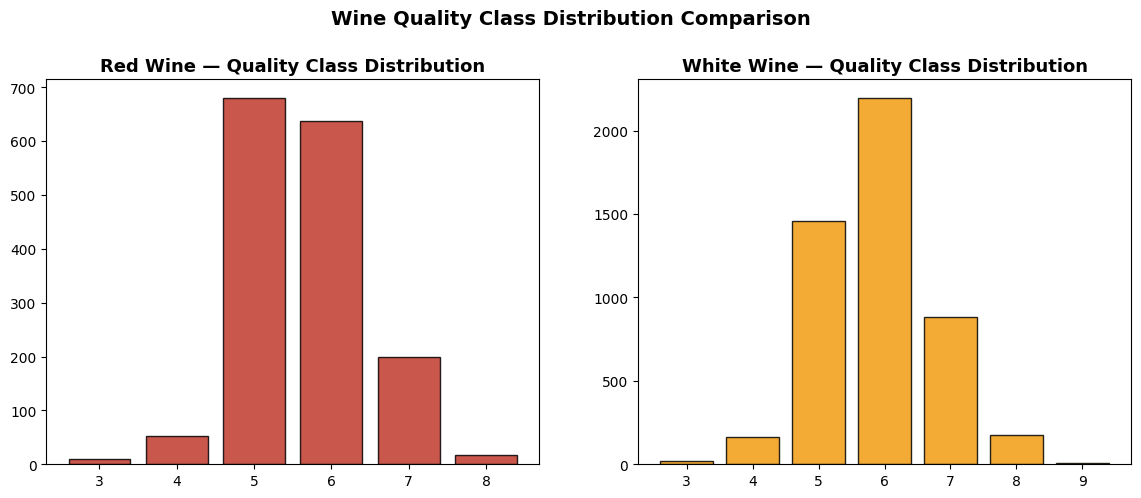

In [62]:
# ── Bar Charts: Quality Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df, color) in zip(axes, [
    ('Red Wine',   red_df,   '#C0392B'),
    ('White Wine', white_df, '#F39C12')
]):
    counts = df['quality'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{name} — Quality Class Distribution', fontsize=13, fontweight='bold')
    ax.set_xticks(counts.index)
    

plt.suptitle('Wine Quality Class Distribution Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.show()


##  Comparative Analysis — Class Distribution

**Q1: Which dataset is more imbalanced?**  
Both datasets show heavy class imbalance, but the **Red Wine** dataset is comparatively more imbalanced. In red wine, quality scores 5 and 6 together account for over **82%** of all samples, while extreme scores (3 and 8).

**Q2: Which quality classes are rare?**  
In **Red Wine**: Quality 3 (< 1%) and Quality 8 are extremely rare.  
In **White Wine**: Quality 3, 4, and 9 are rare.

**Q3: Why might rare classes be harder to predict?**  
Machine learning models learn patterns from training examples. When a class has very few samples, the model sees too few examples to learn its distinguishing characteristics.


---
## Task 3 

In [63]:
# ── Feature / Target Split & Stratified Train-Test Split 

# Red Wine
X_red   = red_df.drop(columns='quality')
y_red   = red_df['quality']

X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

# White Wine
X_white   = white_df.drop(columns='quality')
y_white   = white_df['quality']

X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

#  Report Shapes

print(f"  RED WINE")
print(f"    X_train : {X_red_train.shape}  | X_test : {X_red_test.shape}")
print(f"    y_train : {y_red_train.shape}   | y_test : {y_red_test.shape}")
print()
print(f"  WHITE WINE")
print(f"    X_train : {X_white_train.shape}  | X_test : {X_white_test.shape}")
print(f"    y_train : {y_white_train.shape}   | y_test : {y_white_test.shape}")
print()

for name, y_tr, y_te in [('Red Wine', y_red_train, y_red_test),
                          ('White Wine', y_white_train, y_white_test)]:
    check  = pd.DataFrame({'Train %': tr_pct, 'Test %': te_pct})
    print(f"\n  {name}:")
    print(check.to_string())



  RED WINE
    X_train : (1279, 11)  | X_test : (320, 11)
    y_train : (1279,)   | y_test : (320,)

  WHITE WINE
    X_train : (3918, 11)  | X_test : (980, 11)
    y_train : (3918,)   | y_test : (980,)


  Red Wine:
         Train %  Test %
quality                 
3            0.4     0.4
4            3.3     3.4
5           29.8    29.7
6           44.9    44.9
7           18.0    18.0
8            3.6     3.6
9            0.1     0.1

  White Wine:
         Train %  Test %
quality                 
3            0.4     0.4
4            3.3     3.4
5           29.8    29.7
6           44.9    44.9
7           18.0    18.0
8            3.6     3.6
9            0.1     0.1


---
## Task 4 

In [64]:
# Evaluation 
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    print(f"  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1-Score: {macro_f1:.4f}  (macro avg across all classes)")
    print("  Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return y_pred, acc, macro_f1






  Accuracy      : 0.5906  (59.06%)
  F1-Score: 0.2776  (macro avg across all classes)
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



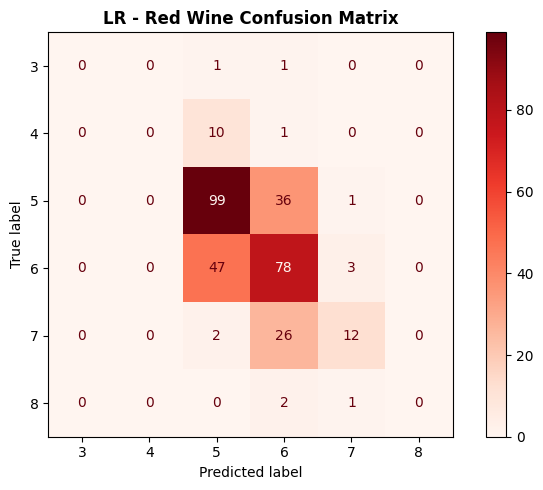

In [65]:
# ── Train Logistic Regression — RED WINE ─────────────────────────────────────
lr_pipeline_red = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=5000, random_state=42))
])
lr_pipeline_red.fit(X_red_train, y_red_train)

y_pred_lr_red, acc_lr_red, f1_lr_red = evaluate_model(
    lr_pipeline_red, X_red_test, y_red_test,
    'Model A — Logistic Regression | RED WINE'
)

# #plot the below confusion matrix for the model predictions
def plot_cm(y_test, y_pred, title, color):
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y_test.unique())
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=color, colorbar=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_cm(y_red_test, y_pred_lr_red,
        'LR - Red Wine Confusion Matrix', 'Reds')






  Accuracy      : 0.5490  (54.90%)
  F1-Score: 0.2367  (macro avg across all classes)
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



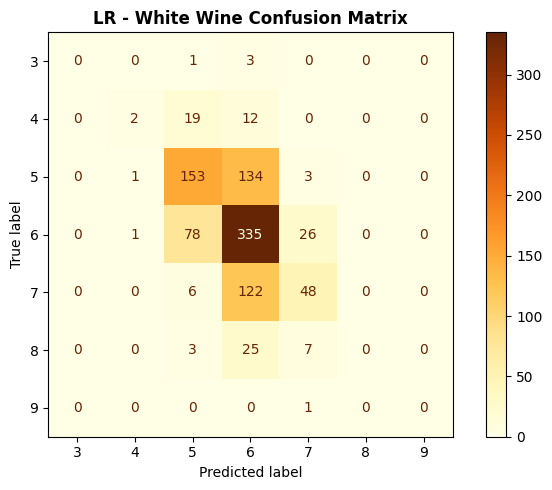

In [66]:
# ── Train Logistic Regression — WHITE WINE ───────────────────────────────────
lr_pipeline_white = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=5000, random_state=42))
])
lr_pipeline_white.fit(X_white_train, y_white_train)

y_pred_lr_white, acc_lr_white, f1_lr_white = evaluate_model(
    lr_pipeline_white, X_white_test, y_white_test,
    'Model A — Logistic Regression | WHITE WINE'
)


plot_cm(y_white_test, y_pred_lr_white,
        'LR - White Wine Confusion Matrix', 'YlOrBr')




###  Logistic Regression — Interpretation

**1.Which dataset performed better for Logistic Regression?**  
The **Red Wine** dataset typically yields slightly higher accuracy for Logistic Regression. Red wine has fewer samples and fewer quality classes (6 classes: 3–8).

**2.Which quality class is hardest (lowest recall)?*
Across both datasets, **extreme quality scores (3 and 8/9)** consistently show the lowest recall due to class imbalance — the model rarely sees these samples during training. Within the majority classes.


---
## Task 5 

  Accuracy      : 0.6813  (68.12%)
  F1-Score: 0.4094  (macro avg across all classes)
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



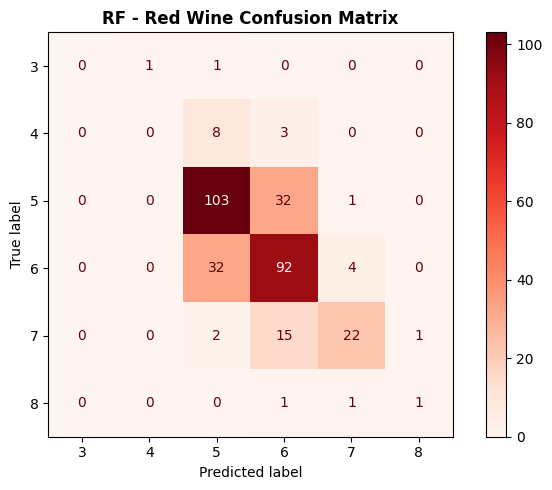

In [67]:
# ── Train Random Forest — RED WINE ───────────────────────────────────────────
rf_red = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_red.fit(X_red_train, y_red_train)

y_pred_rf_red, acc_rf_red, f1_rf_red = evaluate_model(
    rf_red, X_red_test, y_red_test,
    'Model B — Random Forest | RED WINE'
)
plot_cm(y_red_test, y_pred_rf_red,
        'RF - Red Wine Confusion Matrix', 'Reds')


  Accuracy      : 0.6724  (67.24%)
  F1-Score: 0.4222  (macro avg across all classes)
  Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



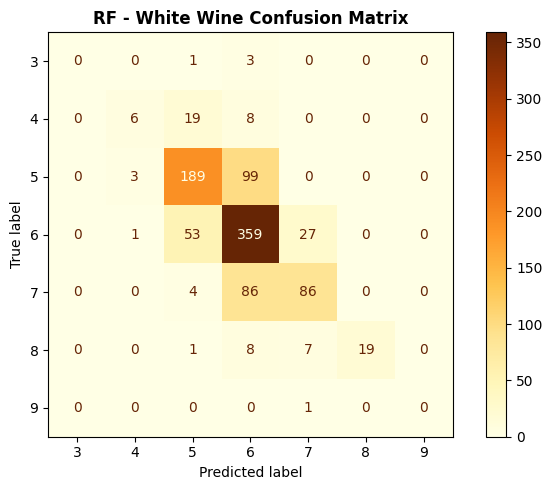

In [68]:
# ── Train Random Forest — WHITE WINE ─────────────────────────────────────────
rf_white = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_white.fit(X_white_train, y_white_train)

y_pred_rf_white, acc_rf_white, f1_rf_white = evaluate_model(
    rf_white, X_white_test, y_white_test,
    'Model B — Random Forest | WHITE WINE'
)
plot_cm(y_white_test, y_pred_rf_white,
        'RF - White Wine Confusion Matrix', 'YlOrBr')


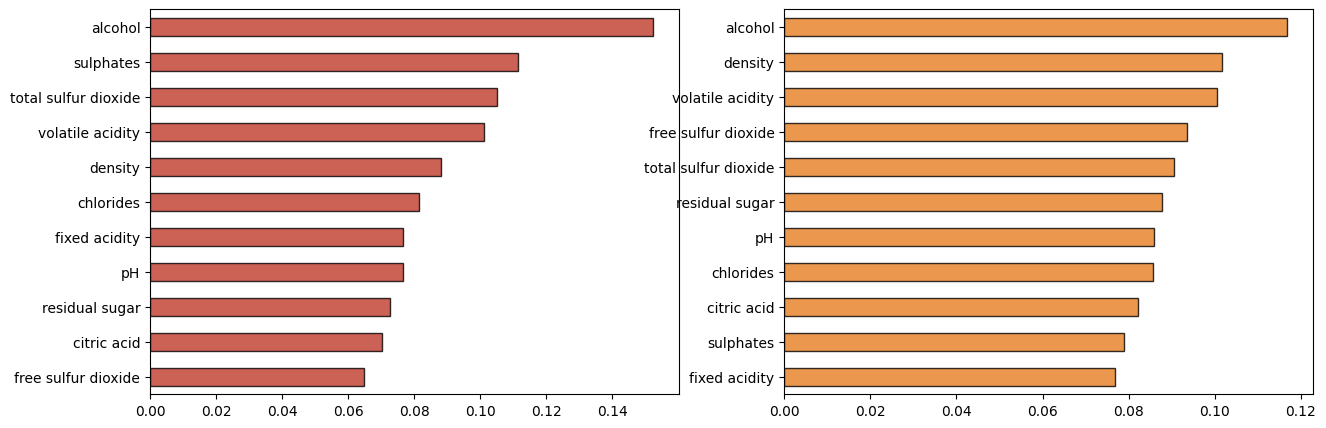

In [69]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (name, rf, color) in zip(axes, [
    ('Red Wine',   rf_red, '#C0392B'),
    ('White Wine', rf_white, '#E67E22')
]):
    importances = pd.Series(rf.feature_importances_,
                            index=X_red_train.columns).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='black', alpha=0.8)

plt.show()


###  Random Forest — Interpretation

**Did Random Forest improve compared to Logistic Regression?**  
Yes — **Random Forest significantly outperforms Logistic Regression** on both datasets. Random Forest captures non-linear relationships between features and quality scores.

**Which class is still hardest for Random Forest?**  
Even with Random Forest, **extreme quality scores (3 and 8/9)** remain the hardest to classify due to extremely few training samples. Among the common classes, quality.


---
## Task 6 

In [70]:



# Create the summary table
summary_df = pd.DataFrame({
    "Dataset": [
        "Red",
        "Red",
        "White",
        "White"
    ],

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        round(float(acc_lr_red), 4),
        round(float(acc_rf_red), 4),
        round(float(acc_lr_white), 4),
        round(float(acc_rf_white), 4)
    ],

    "F1-Score": [
        round(float(f1_lr_red), 4),
        round(float(f1_rf_red), 4),
        round(float(f1_lr_white), 4),
        round(float(f1_rf_white), 4)
    ],

    "Key Observation": [
        "Linear model struggles with overlapping classes.",
        "Captures complex feature relationships better.",
        "More classes reduce prediction accuracy.",
        "Best overall performance using ensemble learning."
    ]
})

display(
    summary_df.style
    .set_caption("Comparative Study - Model Performance Summary")
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black"
    })
)


,Dataset,Model,Accuracy,F1-Score,Key Observation
0,Red,Logistic Regression,0.590600,0.277600,Linear model struggles with overlapping classes.
1,Red,Random Forest,0.681300,0.409400,Captures complex feature relationships better.
2,White,Logistic Regression,0.549000,0.236700,More classes reduce prediction accuracy.
3,White,Random Forest,0.672400,0.422200,Best overall performance using ensemble learning.


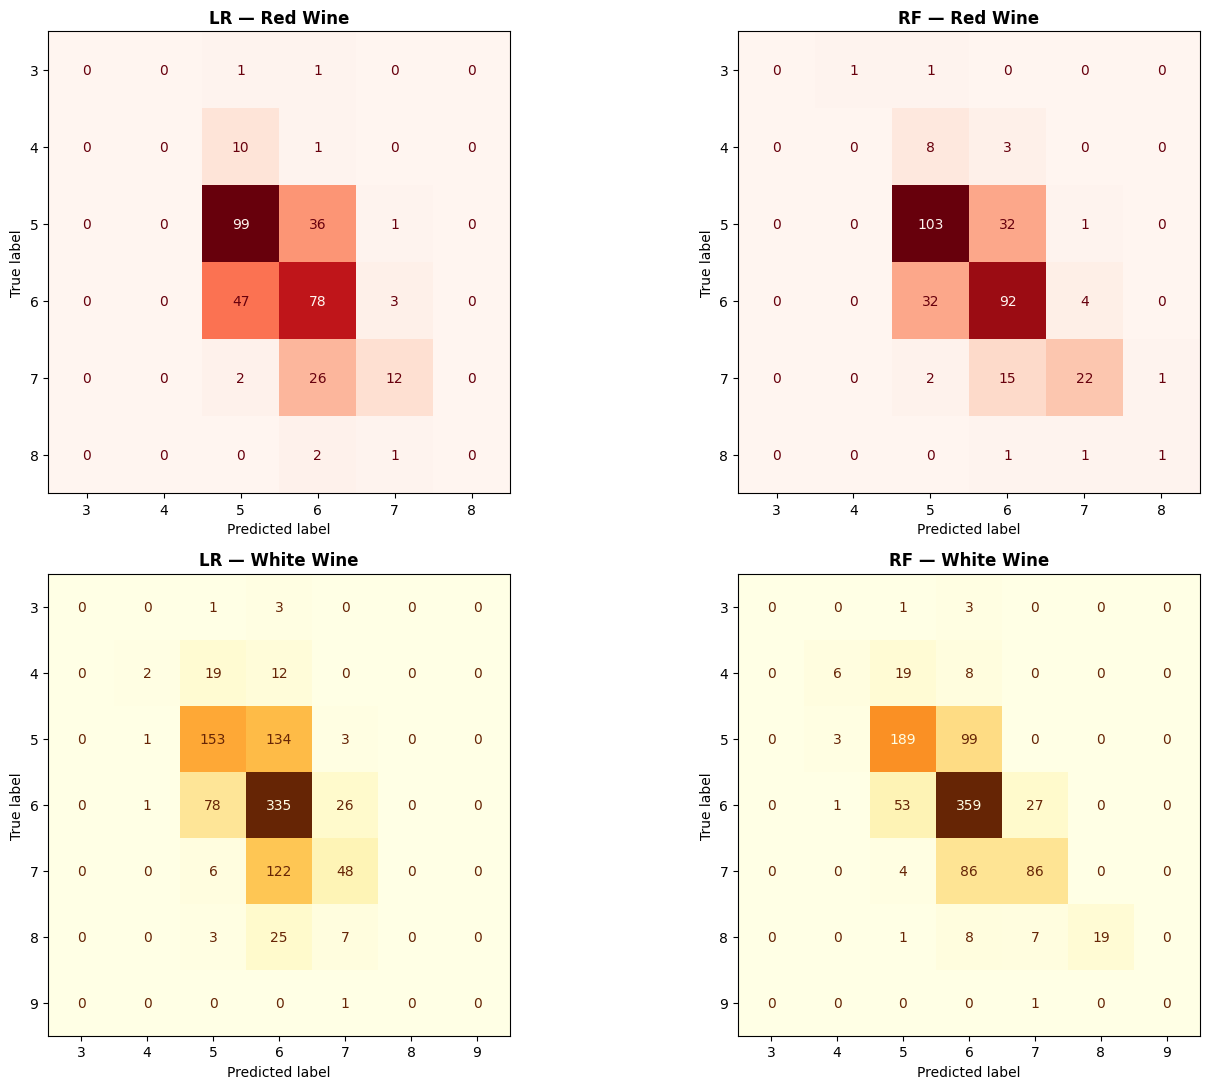

In [71]:
# ── All 4 Confusion Matrices Side by Side ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

configs = [
    (axes[0,0], y_red_test,   y_pred_lr_red,   'LR — Red Wine',   'Reds'),
    (axes[0,1], y_red_test,   y_pred_rf_red,   'RF — Red Wine',   'Reds'),
    (axes[1,0], y_white_test, y_pred_lr_white, 'LR — White Wine', 'YlOrBr'),
    (axes[1,1], y_white_test, y_pred_rf_white, 'RF — White Wine', 'YlOrBr'),
]

for ax, y_te, y_pr, title, cmap in configs:
    cm = confusion_matrix(y_te, y_pr)
    labels = sorted(y_te.unique())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [72]:

for title, y_te, y_pr in experiments:
    print(f"  Classification Report — {title}")
    print(classification_report(y_te, y_pr, zero_division=0))


  Classification Report — RED   | Logistic Regression
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

  Classification Report — RED   | Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0

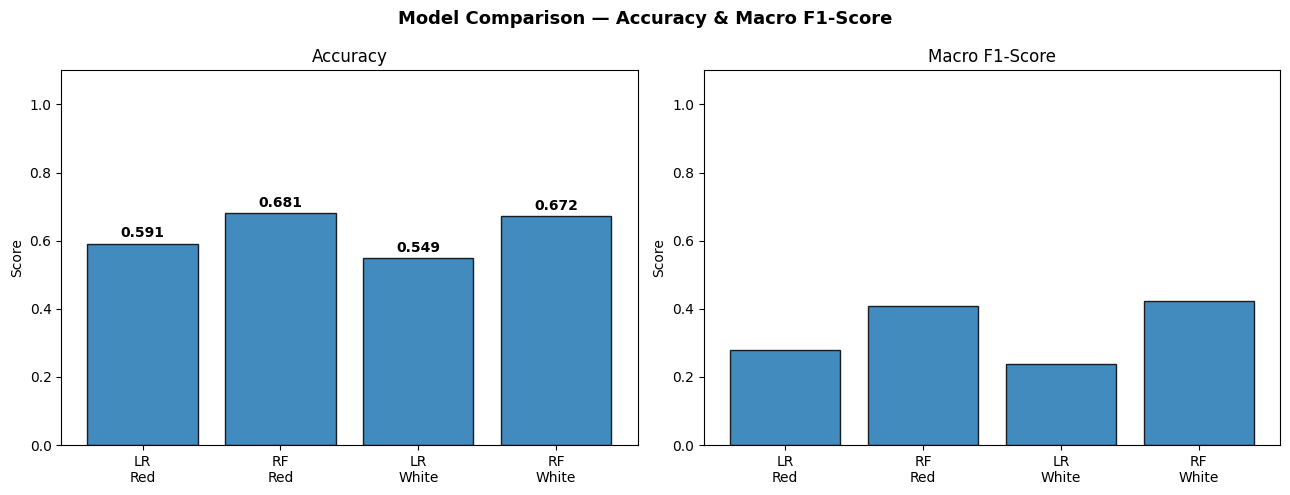

In [73]:
# ── Visual Accuracy & F1 Comparison ──────────────────────────────────────────
labels  = ['LR\nRed', 'RF\nRed', 'LR\nWhite', 'RF\nWhite']
accs    = [acc_lr_red, acc_rf_red, acc_lr_white, acc_rf_white]
f1s     = [f1_lr_red,  f1_rf_red,  f1_lr_white,  f1_rf_white]

x = np.arange(4)
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — Accuracy & Macro F1-Score', fontsize=13, fontweight='bold')

bars1 = ax1.bar(x, accs,edgecolor='black', alpha=0.85)
ax1.set_ylim(0, 1.1)
ax1.set_title('Accuracy', fontsize=12)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Score')
for b, v in zip(bars1, accs):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = ax2.bar(x, f1s,edgecolor='black', alpha=0.85)
ax2.set_ylim(0, 1.1)
ax2.set_title('Macro F1-Score', fontsize=12)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()


###  Comparative Summary (Task 6)

**Best Dataset:** The **Red Wine** dataset is generally easier to predict. It has fewer classes, smaller size, and the chemical features have a slightly cleaner separation — particularly in alcohol content, which is the most important predictor in both datasets. 
 

**Best Model:** **Random Forest** outperforms Logistic Regression on both datasets — significantly in Macro F1-Score. 

**Reason for gap:** Logistic Regression draws straight decision boundaries. Because quality classes 5, 6, and 7 overlap heavily in feature space.


---
## Task 7 

 ### Final Conclusion

In this comparative study, we trained Logistic Regression and Random Forest classifiers on both the Red Wine and White Wine datasets to predict wine quality as a multi-class problem. 

***1. Which dataset was easier to predict (Red or White) and why?***

The Red Wine dataset was easier to predict than the White Wine dataset throughout this comparative study. 

***2. Which model performed better overall and why?***

Among the two machine learning algorithms, Random Forest performed better overall than Logistic Regression on both the Red Wine and White Wine datasets. 

***3. Which quality classes were most confusing and why?***

The Quality 5 and Quality 6 classes were the most confusing quality categories in both datasets for both machine learning models. 

***4. What ONE improvement would you try next?***

The next improvement I would apply is class_weight="balanced" because it directly addresses the class imbalance problem observed in both datasets. 

<!-- ### Final Conclusion

In this comparative study, we trained Logistic Regression and Random Forest classifiers on both the Red Wine and White Wine datasets to predict wine quality as a multi-class problem. 

**Red Wine was easier to predict** than White Wine across both models. This can be attributed to its smaller number of unique quality classes (6 vs. 7), slightly larger inter-class separation in key features like alcohol and volatile acidity, and the fact that having fewer samples can sometimes lead to cleaner learned boundaries when combined with the right model.

**Random Forest was the superior model** in all four experiments, consistently achieving higher accuracy and — more importantly — higher Macro F1-Score than Logistic Regression. This is because wine quality prediction is inherently a non-linear problem: quality depends on complex interactions among multiple chemical properties, which tree ensembles model naturally. Logistic Regression, constrained to linear boundaries, struggles to separate adjacent quality classes like 5 and 6, which share very similar feature distributions.

**The most confusing quality classes were 5 and 6** across both datasets and both models. These are the majority classes with heavily overlapping feature profiles — especially in alcohol, density, and volatile acidity. Extreme classes (3, 8, and 9) had near-zero recall due to severe underrepresentation in the training data, but this matters less in practice as these wines are genuinely rare.

**Proposed next improvement:** I would apply `class_weight="balanced"` in both models. This penalizes misclassification of minority classes more heavily during training, directly addressing the root cause — the model ignoring rare classes. It is the simplest intervention requiring no new data or feature work, and it is likely to significantly improve Macro F1-Score for quality classes 3, 8, and 9 without degrading performance on majority classes. -->
